# 04 Feature Sanity Check

Introduces the validation workflow for extracted VAD features across train/dev/test.
Checks covered in this notebook:
- frame-label length match: `X.shape[0] == y.shape[0]`
- stacked feature dimension: `X.shape[1] == 1331`
- binary labels only (`0/1`)
- no NaN/Inf values
- normalization sanity checks
- optional feature-energy vs label plots

### Imports and Reproducibility
Imports required libraries and sets random seeds for repeatable checks.

In [ ]:
from pathlib import Path
import json
import random

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 4)
SEED = 1337
random.seed(SEED)
np.random.seed(SEED)

### Resolve Project Paths and Feature Manifests
Finds the project root and builds per-split paths to feature manifests.

In [ ]:
def find_project_root(start: Path) -> Path:
    start = start.resolve()
    candidates = [start] + list(start.parents)
    for c in candidates:
        if (c / 'data' / 'generated').exists() and (c / 'src').exists():
            return c
    raise FileNotFoundError('Could not find project root containing data/generated and src')

ROOT = find_project_root(Path.cwd())
print('Project root:', ROOT)

SPLITS = ['train', 'dev', 'test']
MANIFEST_TYPE = 'noisy'
FEATURE_MANIFESTS = {
    s: ROOT / 'data' / 'generated' / s / 'features' / f'{s}_{MANIFEST_TYPE}_features_manifest.jsonl'
    for s in SPLITS
}

for s, p in FEATURE_MANIFESTS.items():
    print(f'{s:5s} -> {p} | exists={p.exists()}')

Project root: /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL
train -> /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/data/generated/train/features/train_noisy_features_manifest.jsonl | exists=True
dev   -> /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/data/generated/dev/features/dev_noisy_features_manifest.jsonl | exists=True
test  -> /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/data/generated/test/features/test_noisy_features_manifest.jsonl | exists=True


### Load Feature Manifests
Reads JSONL manifests into memory so each sample can be validated.

In [ ]:
def read_jsonl(path: Path):
    rows = []
    with path.open('r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

rows_by_split = {s: read_jsonl(p) for s, p in FEATURE_MANIFESTS.items()}
for s in SPLITS:
    print(f'{s:5s}: {len(rows_by_split[s])} rows')

train: 3000 rows
dev  : 500 rows
test : 500 rows


### Run Integrity Checks
1. frame/label length match (X.shape[0] == y.shape[0])
2. stacked feature size (X.shape[1] == 1331)
3. binary labels (0/1)
4. no NaN/Inf values

In [ ]:
def check_split(split: str, rows: list[dict], expected_dim: int = 1331):
    failures = []
    total = len(rows)

    for i, row in enumerate(rows):
        ex_id = row.get('ex_id', f'{split}_{i:07d}')

        x_rel = row.get('stacked_features_path')
        y_rel = row.get('stacked_labels_path')
        if x_rel is None or y_rel is None:
            failures.append((ex_id, 'missing_stacked_paths'))
            continue

        x_path = ROOT / 'data' / 'generated' / split / x_rel
        y_path = ROOT / 'data' / 'generated' / split / y_rel

        if not x_path.exists():
            failures.append((ex_id, f'missing_file:{x_rel}'))
            continue
        if not y_path.exists():
            failures.append((ex_id, f'missing_file:{y_rel}'))
            continue

        X = np.load(x_path)
        y = np.load(y_path)

        if X.ndim != 2:
            failures.append((ex_id, f'X_ndim_{X.ndim}_not_2'))
            continue
        if y.ndim != 1:
            failures.append((ex_id, f'y_ndim_{y.ndim}_not_1'))
            continue

        if X.shape[0] != y.shape[0]:
            failures.append((ex_id, f'shape_mismatch_X0_{X.shape[0]}_y0_{y.shape[0]}'))

        if X.shape[1] != expected_dim:
            failures.append((ex_id, f'bad_feature_dim_{X.shape[1]}'))

        uniq = np.unique(y)
        if not np.all(np.isin(uniq, [0, 1])):
            failures.append((ex_id, f'non_binary_labels_{uniq.tolist()}'))

        if not np.isfinite(X).all():
            failures.append((ex_id, 'X_has_nan_or_inf'))
        if not np.isfinite(y).all():
            failures.append((ex_id, 'y_has_nan_or_inf'))

    return {'split': split, 'total': total, 'num_failures': len(failures), 'failures': failures}

results = {s: check_split(s, rows_by_split[s]) for s in SPLITS}
for s in SPLITS:
    r = results[s]
    print(f"{s:5s} | total={r['total']} | failures={r['num_failures']}")

train | total=3000 | failures=0
dev   | total=500 | failures=0
test  | total=500 | failures=0


### Display Failure Details
Prints a compact, human-readable list of failing examples (if any).

In [ ]:
MAX_SHOW = 20
for s in SPLITS:
    fails = results[s]['failures']
    if not fails:
        print(f'{s:5s}: PASS')
        continue
    print(f'\n{s:5s}: first {min(MAX_SHOW, len(fails))} failures')
    for ex_id, reason in fails[:MAX_SHOW]:
        print(' -', ex_id, '|', reason)

train: PASS
dev  : PASS
test : PASS


### Check Normalization Quality (Train Frame Features)
Summarizes train-frame mean/std to confirm normalization was applied correctly.

In [ ]:
# Normalization sanity check on train frame-level 121-dim features
# Train should be approximately zero-mean, unit-variance after normalization.
train_rows = rows_by_split['train']

sum_x = None
sum_x2 = None
n_total = 0

for row in train_rows:
    frame_rel = row['frame_features_path']
    frame_path = ROOT / 'data' / 'generated' / 'train' / frame_rel
    Xf = np.load(frame_path).astype(np.float64, copy=False)

    if sum_x is None:
        D = Xf.shape[1]
        sum_x = np.zeros(D, dtype=np.float64)
        sum_x2 = np.zeros(D, dtype=np.float64)

    sum_x += Xf.sum(axis=0)
    sum_x2 += (Xf * Xf).sum(axis=0)
    n_total += Xf.shape[0]

mean = sum_x / n_total
var = (sum_x2 / n_total) - (mean ** 2)
std = np.sqrt(np.maximum(var, 0.0))

print('Train frame feature normalization summary (121 dims):')
print('  mean(abs(mean)):', float(np.mean(np.abs(mean))))
print('  max(abs(mean)) :', float(np.max(np.abs(mean))))
print('  mean(std)      :', float(np.mean(std)))
print('  min(std), max(std):', float(np.min(std)), float(np.max(std)))

Train frame feature normalization summary (121 dims):
  mean(abs(mean)): 2.2609274037833357e-08
  max(abs(mean)) : 1.310381363675118e-07
  mean(std)      : 1.000000000197654
  min(std), max(std): 0.9999999392617126 1.0000000490380783


### Validate Stacked Feature Consistency
Verifies each stacked vector's center block matches the corresponding normalized frame feature.

In [ ]:
# Check stacked-vs-frame consistency for a random subset:
# center context block in stacked feature should match frame feature.
SAMPLE_N = 25
left = int(train_rows[0].get('context_left', 5))
frame_dim = int(train_rows[0].get('frame_dim', 121))
start = left * frame_dim
end = start + frame_dim

subset = random.sample(train_rows, k=min(SAMPLE_N, len(train_rows)))
max_err = 0.0

for row in subset:
    frame_path = ROOT / 'data' / 'generated' / 'train' / row['frame_features_path']
    stacked_path = ROOT / 'data' / 'generated' / 'train' / row['stacked_features_path']

    Xf = np.load(frame_path)
    Xs = np.load(stacked_path)
    T = min(Xf.shape[0], Xs.shape[0])

    center = Xs[:T, start:end]
    err = float(np.max(np.abs(center - Xf[:T, :])))
    max_err = max(max_err, err)

print(f'Checked {len(subset)} samples')
print('Max abs error between stacked center block and frame feature:', max_err)
print('PASS' if max_err < 1e-5 else 'WARNING: mismatch larger than expected')

Checked 25 samples
Max abs error between stacked center block and frame feature: 0.0
PASS


### Visualization: Feature Energy vs Labels
Plots per-frame feature energy and overlays labels to spot alignment trends.

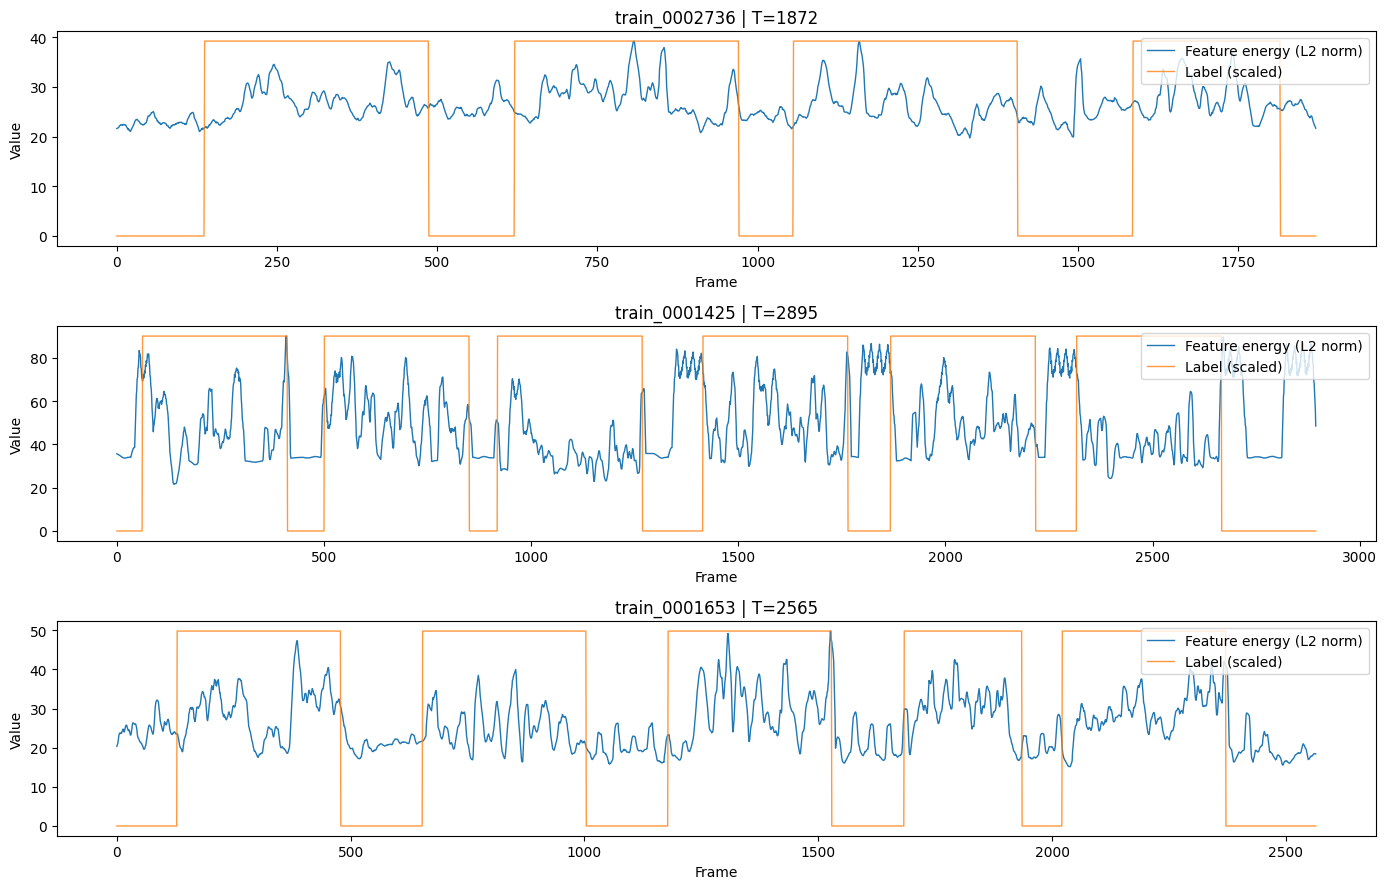

In [ ]:
# Energy proxy: L2 norm per frame of 1331-dim stacked feature
N_PLOTS = 3
plot_rows = random.sample(train_rows, k=min(N_PLOTS, len(train_rows)))

fig, axes = plt.subplots(len(plot_rows), 1, figsize=(14, 3 * max(1, len(plot_rows))), sharex=False)
if len(plot_rows) == 1:
    axes = [axes]

for ax, row in zip(axes, plot_rows):
    X = np.load(ROOT / 'data' / 'generated' / 'train' / row['stacked_features_path'])
    y = np.load(ROOT / 'data' / 'generated' / 'train' / row['stacked_labels_path'])

    T = min(len(X), len(y))
    energy = np.linalg.norm(X[:T], axis=1)
    yy = y[:T].astype(float)

    ax.plot(energy, label='Feature energy (L2 norm)', linewidth=1.0)
    ax.plot(yy * np.max(energy), label='Label (scaled)', linewidth=1.0, alpha=0.8)
    ax.set_title(f"{row['ex_id']} | T={T}")
    ax.set_xlabel('Frame')
    ax.set_ylabel('Value')
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()